# <font color = 'red'> Dependencias

In [2]:
import pandas as pd

import sys
import os

# Agregar la carpeta calibration_code al path
sys.path.append(os.path.abspath("../../calibration_code"))

# Ahora puedes importar los módulos personalizados
from modelling_tools import plot_histogram, plot_univariate_freq
from utils import g
from config import get_data_path, get_code_path
from data_cleaning import check_dataframe_quality

# <font color = 'red'> Carga de Datos

In [3]:
df = pd.read_csv(get_data_path("Credit_score_cleaned_data.csv"))

# <font color = 'red'> Análisis

In [ ]:
# En Last_Loan_1, Last_Loan_2 y Last_Loan_3, todas las categorías distintas de "No Loan" representan más del 5% del total.
# En Last_Loan_4, la categoría con menor peso es 4.72%, cerca del umbral del 5%, lo que sugiere una ligera reducción en la diversidad de préstamos.
# A partir de Last_Loan_5, todas las categorías distintas de "No Loan" pesan menos del 4%, disminuyendo gradualmente.
# En Last_Loan_9, las categorías distintas de "No Loan" tienen una representatividad menor al 0.52%, mostrando una clara tendencia de reducción.
# "No Loan" aumenta progresivamente en peso a medida que disminuyen las otras categorías, lo cual es natural, ya que todas las categorías 
# deben sumar 100%.

# Posible interpretación:

# A medida que avanzamos en el historial de préstamos anteriores (Last_Loan_5 en adelante), la mayoría de los clientes ya no tienen un préstamo 
# registrado, lo que podría indicar una menor relevancia de estos datos más antiguos para predecir el comportamiento actual.
# La disminución progresiva de las categorías distintas de "No Loan" sugiere que los datos más recientes (Last_Loan_1 - Last_Loan_3) son más 
# # representativos del comportamiento crediticio actual del cliente.

# Hipótesis: 

# Last_Loan_1 es el más reciente → Mayor impacto en el perfil financiero actual del cliente.
# Last_Loan_9 es el más antiguo → Menor relevancia, pero aún puede influir si el cliente tenía préstamos de alto riesgo en el pasado.
# Algunos tipos de préstamos son naturalmente más riesgosos que otros debido a sus características:

# Decisión metodológica
# no considerar Last_Loan_5 en adelante

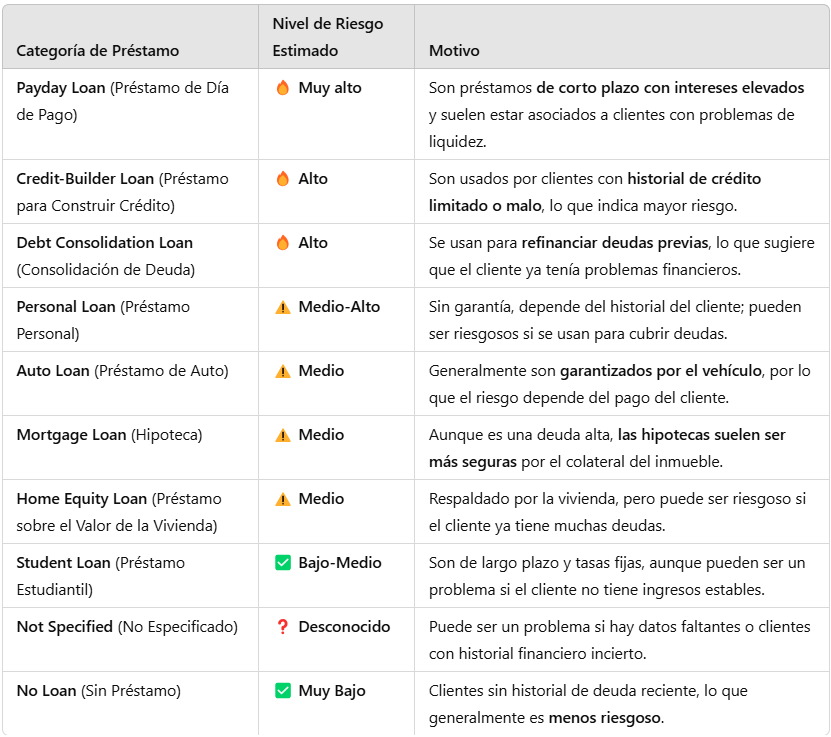

In [28]:
for i in range(1, 10):
    fig = plot_univariate_freq(df, f'Last_Loan_{i}', figsize=(900, 600), normalize=True)
    fig.show()
    print('\n')

In [6]:
g(df[['Monthly_Balance']].describe(percentiles=[0.15, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).transpose(), 0)

,count,mean,std,min,15%,25%,50%,75%,90%,95%,99%,max
Monthly_Balance,"100,000",403,214,0,242,270,337,472,711,864,"1,139","1,602"


In [ ]:
# Todas las variables Last_Loan tienen las mismas categorías:

loan_columns = [f"Last_Loan_{i}" for i in range(1, 10)]  # Lista de nombres de columnas
unique_categories = {col: df[col].unique() for col in loan_columns}  # Obtener categorías únicas

# Mostrar las categorías de cada variable
#for col, categories in unique_categories.items():
#    print(f"{col}: {categories}")


# Crear un conjunto con todas las categorías únicas
all_categories = set(df["Last_Loan_1"].unique())

# Verificar si todas las columnas tienen exactamente las mismas categorías
for col in loan_columns:
    if set(df[col].unique()) != all_categories:
        print(f"⚠️ Diferencias encontradas en {col}")
    else:
        print(f"✅ {col} tiene las mismas categorías.")

✅ Last_Loan_1 tiene las mismas categorías.
✅ Last_Loan_2 tiene las mismas categorías.
✅ Last_Loan_3 tiene las mismas categorías.
✅ Last_Loan_4 tiene las mismas categorías.
✅ Last_Loan_5 tiene las mismas categorías.
✅ Last_Loan_6 tiene las mismas categorías.
✅ Last_Loan_7 tiene las mismas categorías.
✅ Last_Loan_8 tiene las mismas categorías.
✅ Last_Loan_9 tiene las mismas categorías.
